# Week 6 · Day 2 — Polynomial Regression + The Bridge to Classification

Yesterday we fit **straight lines** through data — even with many features, the model was linear. But not every relationship is a straight line. Some **curve**: a car loses value fast at first then levels off; crop yield rises with rainfall then falls when there's too much.

Today we learn to fit **curves** — and the trick is delightful: we do it with the *exact same linear regression*, just fed cleverer features. Then we meet the two most important words in machine learning — **underfitting** and **overfitting** — and finish by setting up the big shift coming tomorrow: from predicting *numbers* to predicting *categories*.

**The plan:**
1. Why a straight line isn't always enough.
2. Fit a curve from scratch — by adding `x²`, `x³` as features.
3. Underfitting vs overfitting — the central lesson.
4. The bridge: when the answer is a category, not a number.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## 1. When a straight line isn't enough

Let's make some data that clearly **curves** — it rises, peaks, and falls. Think of something like *hours of study vs energy level*: a little study energizes, too much exhausts.

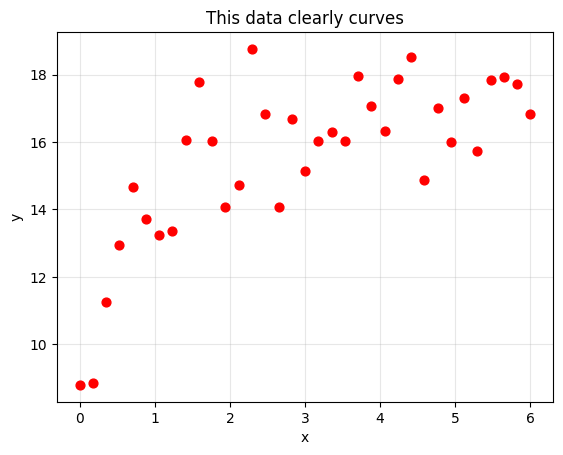

In [3]:
# Data that follows a curve (with some noise)
rng = np.random.default_rng(5)
x = np.linspace(0, 6, 35)
y_true = 10 + 5*x - 1.2*x**2 + 0.1*x**3        # the real underlying curve
y = y_true + rng.normal(0, 1.5, len(x))         # add realistic noise

plt.scatter(x, y, color="red", s=40, zorder=3)
plt.xlabel("x"); plt.ylabel("y"); plt.title("This data clearly curves")
plt.grid(True, alpha=0.3)
plt.show()

Now let's try fitting yesterday's **straight line** to it and see how badly it does.

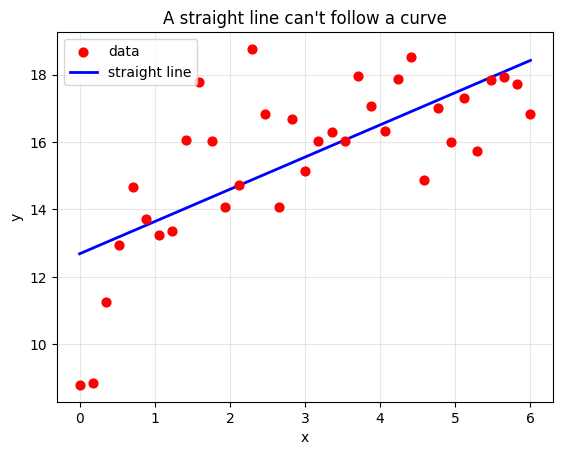

In [4]:
from sklearn.linear_model import LinearRegression

# fit a straight line (degree 1)
X = x.reshape(-1, 1)                # sklearn wants a 2D column
line_model = LinearRegression().fit(X, y)

plt.scatter(x, y, color="red", s=40, zorder=3, label="data")
plt.plot(x, line_model.predict(X), color="blue", linewidth=2, label="straight line")
plt.xlabel("x"); plt.ylabel("y"); plt.title("A straight line can't follow a curve")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

The line cuts straight through the middle, missing the rise and the fall entirely. It **underfits** — it's too simple for this data. We need something that can bend.

---
## 2. Fitting a curve — the clever trick

Here's the key insight: **we don't need a new algorithm.** We keep linear regression exactly as it is, and instead give it **new features** — the powers of `x`.

Instead of just `x`, we feed the model `x`, `x²`, and `x³`. Then linear regression finds:

$$ y = w_1 x + w_2 x^2 + w_3 x^3 + b $$

That equation *is* a curve, even though the model fitting it is still "linear" (linear in the weights). This is **polynomial regression**: multiple linear regression where the extra features are powers of the original.

Let's build those features by hand first.

In [5]:
# Build polynomial features from scratch: x, x^2, x^3
x2 = x ** 2
x3 = x ** 3

# stack them into a feature matrix (each column is one feature)
X_poly = np.column_stack([x, x2, x3])
print("shape:", X_poly.shape, " (35 rows, 3 features: x, x², x³)")
print("first 3 rows:")
print(np.round(X_poly[:3], 2))

shape: (35, 3)  (35 rows, 3 features: x, x², x³)
first 3 rows:
[[0.   0.   0.  ]
 [0.18 0.03 0.01]
 [0.35 0.12 0.04]]


Now fit the **same** `LinearRegression` — but on these three features instead of just `x`.

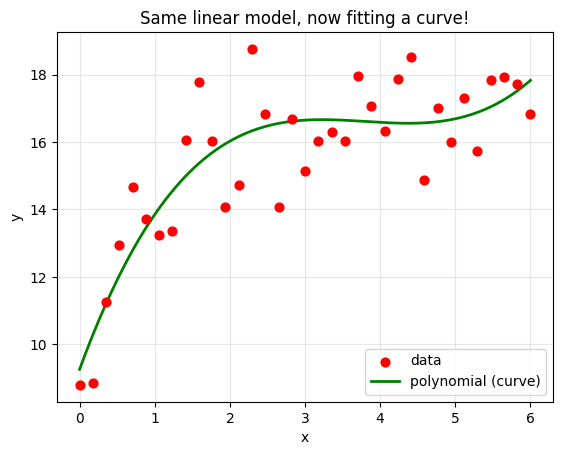

In [6]:
curve_model = LinearRegression().fit(X_poly, y)

# to draw a smooth curve, make dense x values and build their powers too
x_smooth = np.linspace(0, 6, 200)
X_smooth = np.column_stack([x_smooth, x_smooth**2, x_smooth**3])
y_smooth = curve_model.predict(X_smooth)

plt.scatter(x, y, color="red", s=40, zorder=3, label="data")
plt.plot(x_smooth, y_smooth, color="green", linewidth=2, label="polynomial (curve)")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Same linear model, now fitting a curve!")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

The green curve follows the data's rise and fall beautifully — and it was fit by the *same* `LinearRegression` as yesterday. We just gave it `x²` and `x³` to work with. That's the whole idea of polynomial regression.

### scikit-learn does the feature-building for you

Making `x²`, `x³` by hand gets tedious for higher powers. scikit-learn's `PolynomialFeatures` builds them automatically. Watch — it gives the identical result.

In [7]:
from sklearn.preprocessing import PolynomialFeatures

# automatically create all powers up to degree 3
poly = PolynomialFeatures(degree=3, include_bias=False)
X_auto = poly.fit_transform(x.reshape(-1, 1))

print("features created:", poly.get_feature_names_out())
print("shape:", X_auto.shape)   # same 3 columns: x, x^2, x^3

features created: ['x0' 'x0^2' 'x0^3']
shape: (35, 3)


---
## 3. The central lesson: underfitting vs overfitting

How many powers should we use? The **degree** of the polynomial controls how bendy the curve can be. Too few, too many, or just right — this choice is one of the most important ideas in all of machine learning.

To judge honestly, we split into **train** and **test** sets (yesterday's golden rule) and fit three models: degree 1 (a line), degree 4, and degree 15 (very bendy).

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=5)

def fit_poly(degree):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_tr = poly.fit_transform(x_train.reshape(-1, 1))
    X_te = poly.transform(x_test.reshape(-1, 1))
    model = LinearRegression().fit(X_tr, y_train)
    r2_train = r2_score(y_train, model.predict(X_tr))
    r2_test  = r2_score(y_test,  model.predict(X_te))
    return model, poly, r2_train, r2_test

In [9]:
# fit all three and compare how they score on TRAIN vs unseen TEST data
for degree in [1, 4, 15]:
    _, _, r2_tr, r2_te = fit_poly(degree)
    print(f"degree {degree:2d}:  train R² = {r2_tr:.3f}   test R² = {r2_te:.3f}")

degree  1:  train R² = 0.391   test R² = 0.685
degree  4:  train R² = 0.649   test R² = 0.950
degree 15:  train R² = 0.752   test R² = -1.051


Read those numbers carefully — they tell the whole story:

- **degree 1** — poor on *both* train and test. Too simple. This is **underfitting**.
- **degree 4** — good on both, and *best on the test set*. Just right.
- **degree 15** — great on train but **terrible on test** (even negative!). It memorized the training points, including their noise, and fails on new data. This is **overfitting**.

Let's *see* all three curves to make it unforgettable.

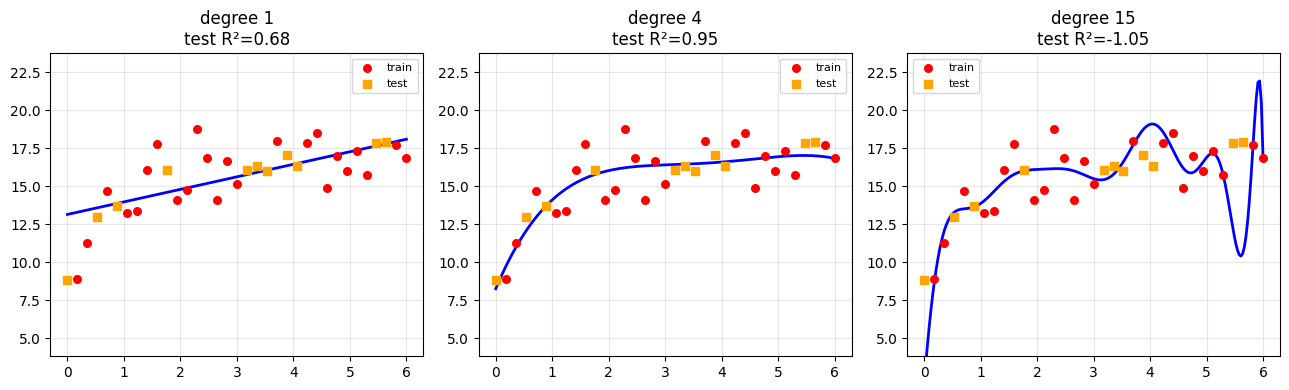

In [10]:
x_smooth = np.linspace(0, 6, 200)
plt.figure(figsize=(13, 4))

for i, degree in enumerate([1, 4, 15], 1):
    model, poly, r2_tr, r2_te = fit_poly(degree)
    X_smooth = poly.transform(x_smooth.reshape(-1, 1))

    plt.subplot(1, 3, i)
    plt.scatter(x_train, y_train, color="red", s=30, zorder=3, label="train")
    plt.scatter(x_test, y_test, color="orange", s=40, marker="s", zorder=3, label="test")
    plt.plot(x_smooth, model.predict(X_smooth), color="blue", linewidth=2)
    plt.ylim(y.min()-5, y.max()+5)
    plt.title(f"degree {degree}\ntest R²={r2_te:.2f}")
    plt.legend(fontsize=8); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Look at the three pictures:

- **Left (degree 1):** a rigid straight line that ignores the curve — *underfit*.
- **Middle (degree 4):** a smooth curve that captures the real shape without chasing every wiggle — *just right*.
- **Right (degree 15):** a wild, thrashing curve that twists to touch the training points but swings wildly between them — *overfit*.

**The plain-English version:** an underfit model is *lazy* — too simple to learn the pattern. An overfit model is a *crammer* — it memorized the training data (and its noise) like a student who memorized past papers but can't answer a new question. What we want is a model that learned the real *pattern* and generalizes to data it's never seen.

**This is why we always keep a test set.** The overfit degree-15 model looked great on training data — if we'd only checked there, we'd have been fooled. The test set exposed the truth.

---
## 4. The bridge: from "how much?" to "which one?"

Everything we've done for two weeks predicts a **number** — a price, a mark, an energy level. That's **regression**.

But a huge share of real problems ask a different kind of question — one with a **category** as the answer:
- Is this email **spam or not**?
- Will this student **pass or fail**?
- Is this tumor **benign or malignant**?

These are **classification** problems, and our regression tools don't quite fit them. Let's see exactly why, so tomorrow's solution feels necessary.

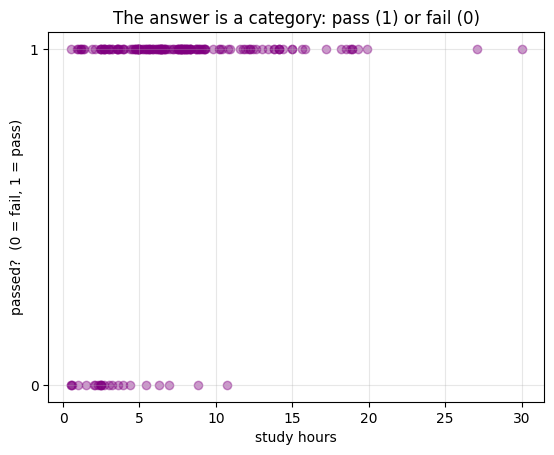

In [12]:
# Take students data, turn marks into a PASS/FAIL category
students = pd.read_csv(r"D:\AI\Artificial-Intelligence-Machine-Learning-and-Deep-Learning-Corvit-Peshawar-2026\Artificial-Inteligence-Machine-Learning-and-Deep-Learning-NAVTTC-Course-2026\week-06-regression-and-classification-ML\datasets\students.csv")
students = students.dropna(subset=["study_hours", "final_marks"])
students["passed"] = (students["final_marks"] >= 50).astype(int)   # 1 = pass, 0 = fail

# plot study hours vs pass/fail (0 or 1)
plt.scatter(students["study_hours"], students["passed"], alpha=0.4, color="purple")
plt.xlabel("study hours"); plt.ylabel("passed?  (0 = fail, 1 = pass)")
plt.title("The answer is a category: pass (1) or fail (0)")
plt.yticks([0, 1]); plt.grid(True, alpha=0.3)
plt.show()

The outputs are only ever **0 or 1** — there's no "in between." Now watch what happens if we try to fit a regression line to this.

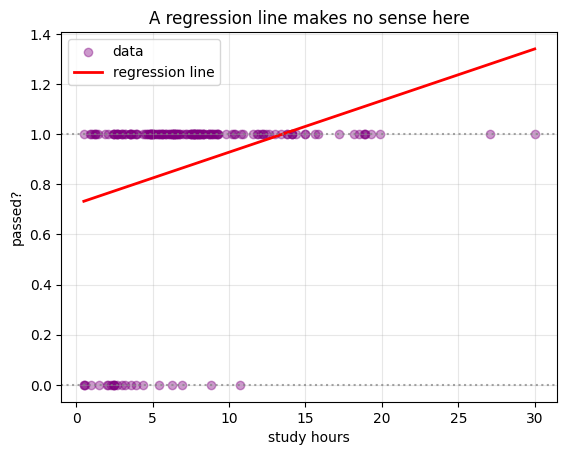

In [13]:
X = students[["study_hours"]].values
y_pass = students["passed"].values
line = LinearRegression().fit(X, y_pass)

x_range = np.linspace(students["study_hours"].min(), students["study_hours"].max(), 100)
plt.scatter(students["study_hours"], students["passed"], alpha=0.4, color="purple", label="data")
plt.plot(x_range, line.predict(x_range.reshape(-1, 1)), color="red", linewidth=2, label="regression line")
plt.axhline(1, color="gray", linestyle=":", alpha=0.7)
plt.axhline(0, color="gray", linestyle=":", alpha=0.7)
plt.xlabel("study hours"); plt.ylabel("passed?")
plt.title("A regression line makes no sense here")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

The line is **absurd for this job**:
- It goes **above 1** and **below 0** — but you can't be "130% likely to pass" or "−20% likely."
- It predicts a smooth number, but we need a clean **yes/no** decision.

What we actually want is something that outputs a **probability** — a number gently squeezed between 0 and 1 — that we can read as "80% likely to pass," then turn into a decision.

**That's tomorrow.** The tool is called **logistic regression**, and its secret ingredient is a function that bends any number into the 0-to-1 range. Same spirit as today — reuse what we know, add one clever piece.

---
## Summary

- **Polynomial regression** fits curves — by feeding **powers of x** (`x²`, `x³`, ...) as extra features to the *same* linear regression. No new algorithm needed.
- `PolynomialFeatures` in scikit-learn builds those power-columns automatically.
- The **degree** controls flexibility, and choosing it is critical:
  - too low → **underfitting** (too simple, misses the pattern),
  - too high → **overfitting** (memorizes noise, fails on new data),
  - just right → captures the real pattern and generalizes.
- **Always judge on a held-out test set** — an overfit model looks perfect on training data and only reveals its failure on unseen data.
- **Regression predicts numbers; classification predicts categories.** A regression line fails for yes/no problems because it isn't bounded between 0 and 1.

Next time: **logistic regression** — we squeeze the line into a probability and start predicting categories.

----

<div style="background:#0d1117;border:1px solid #21262d;border-radius:16px;padding:28px 30px;font-family:'Segoe UI',system-ui,sans-serif;box-shadow:0 6px 20px rgba(0,0,0,0.4);margin-top:15px;">
  <div style="display:flex;align-items:center;border-bottom:1px solid #21262d;padding-bottom:16px;margin-bottom:16px;">
    <img src="https://github.com/M-Abbas1.png" alt="profile"
         style="width:56px;height:56px;border-radius:50%;margin-right:16px;flex-shrink:0;border:2px solid #00c6a2;object-fit:cover;" />
    <div>
      <div style="color:#ffffff;font-size:20px;font-weight:700;">Muhammad Abbas</div>
      <div style="color:#00c6a2;font-size:14px;font-weight:500;">AI / Machine Learning Instructor</div>
    </div>
  </div>
  <div style="color:#8b949e;font-size:14px;line-height:1.9;">
    <div><span style="color:#00c6a2;">&#127891;</span>&nbsp; <b style="color:#c9d1d9;">Course:</b> Artificial Intelligence (Machine Learning &amp; Deep Learning)</div>
    <div><span style="color:#00c6a2;">&#127970;</span>&nbsp; <b style="color:#c9d1d9;">Program:</b> NAVTTC &mdash; Prime Minister&rsquo;s Hunarmand Pakistan &ldquo;Skills for All&rdquo;</div>
    <div style="margin-top:10px;display:flex;align-items:center;flex-wrap:wrap;gap:6px;">
      <img src="https://cdn.simpleicons.org/gmail/00c6a2?size=16" style="vertical-align:middle;" />
      <a href="mailto:mr.mabbas2@gmail.com" style="color:#58a6ff;text-decoration:none;">mr.mabbas2@gmail.com</a>
      &nbsp;&nbsp;|&nbsp;&nbsp;
      
      <a href="https://www.linkedin.com/in/muhammad-abbas-b93524279/" style="color:#58a6ff;text-decoration:none;">LinkedIn</a>
      &nbsp;&nbsp;|&nbsp;&nbsp;
      <img src="https://cdn.simpleicons.org/github/00c6a2?size=16" style="vertical-align:middle;" />
      <a href="https://github.com/M-Abbas1" style="color:#58a6ff;text-decoration:none;">GitHub</a>
    </div>
  </div>
  <div style="border-top:1px solid #21262d;margin-top:16px;padding-top:14px;text-align:center;">
    <span style="color:#6e7681;font-size:13px;font-style:italic;">
      &ldquo;The best way to predict the future is to create it.&rdquo;
    </span>
  </div>
  <div style="text-align:center;margin-top:10px;">
    <span style="color:#484f58;font-size:12px;">&copy; 2026 Muhammad Abbas &nbsp;&bull;&nbsp; Made with &#10084;&#65039; for learning</span>
  </div>
</div>